# Exploratory Data Analysis: DeepFake (MAGE) Dataset

Project: Unknown-Aware LLM-generated Text Detection (CS639 Group 1)

This notebook runs initial EDA on the MAGE dataset (Machine-generated Text Detection in the Wild), also referred to as the DeepFake text dataset. It contains human-written and LLM-generated text across multiple domains.

- Source: [yaful/MAGE on HuggingFace](https://huggingface.co/datasets/yaful/MAGE)
- Paper: [MAGE: Machine-generated Text Detection in the Wild](https://arxiv.org/abs/2305.13242)

## 1. Load dataset

In [1]:
import sys
print(sys.executable)

/Users/AkshatJain/anaconda3/bin/python


In [2]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("yaful/MAGE")
print("Splits:", list(dataset.keys()))

/Users/AkshatJain/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/404M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/72.3M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/71.7M [00:00<?, ?B/s]

...

test_ood_set_gpt_para.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/319071 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/56792 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/60743 [00:00<?, ? examples/s]

Splits: ['train', 'validation', 'test']


## 2. Basic dataset info

In [3]:
for split_name, split_data in dataset.items():
    print(f"{split_name}: {len(split_data):,} rows")
print("\nColumns:", dataset["train"].column_names)
print("\nFeatures:", dataset["train"].features)

train: 319,071 rows
validation: 56,792 rows
test: 60,743 rows

Columns: ['text', 'label', 'src']

Features: {'text': Value('string'), 'label': Value('int64'), 'src': Value('string')}


## 3. Label distribution

Check value counts per split. (Label meaning: often 0=human, 1=machine; verify using `src` e.g. *_human vs *_machine.)

In [4]:
for split_name, split_data in dataset.items():
    counts = split_data["label"]
    print(f"{split_name}:")
    print(pd.Series(counts).value_counts().sort_index())
    print()

train:
0    225753
1     93318
Name: count, dtype: int64

validation:
0    27993
1    28799
Name: count, dtype: int64

test:
0    30478
1    30265
Name: count, dtype: int64



## 4. Source (domain) distribution

The `src` column indicates the domain/source of each sample (e.g. Reddit, BBC, which LLM).

In [5]:
train_src = pd.Series(dataset["train"]["src"])
print("Number of unique sources (train):", train_src.nunique())
print("\nTop 20 sources by count:")
print(train_src.value_counts().head(20))

Number of unique sources (train): 322

Top 20 sources by count:
yelp_human                                 31827
eli5_human                                 16706
squad_human                                15820
wp_human                                    6356
xsum_human                                  4708
sci_gen_human                               4436
cmv_human                                   4223
roct_human                                  3287
hswag_human                                 3129
tldr_human                                  2826
wp_machine_topical_text-davinci-002          800
roct_machine_topical_text-davinci-002        800
roct_machine_topical_gpt-3.5-trubo           800
xsum_machine_topical_gpt-3.5-trubo           800
xsum_machine_continuation_gpt-3.5-trubo      800
wp_machine_specified_text-davinci-003        800
roct_machine_specified_text-davinci-003      800
roct_machine_specified_gpt-3.5-trubo         800
wp_machine_specified_gpt-3.5-trubo           800
xsum_

## 5. Text length statistics

Character and word count per sample (train split).

In [9]:
train = dataset["train"]
texts = train["text"]
labels = train["label"]

char_lens = [len(t) for t in texts]
word_lens = [len(t.split()) for t in texts]

df = pd.DataFrame({"label": labels, "char_len": char_lens, "word_len": word_lens})
df["label_name"] = df["label"].map({0: "machine", 1: "human"})

print("Overall (train):")
print(df[["char_len", "word_len"]].describe())
print("\nBy label:")
print(df.groupby("label_name")[["char_len", "word_len"]].agg(["mean", "median", "min", "max"]))

Overall (train):
            char_len       word_len
count  319071.000000  319071.000000
mean     1228.018334     211.461988
std      1421.562883     243.163859
min        21.000000       6.000000
25%       311.000000      55.000000
50%       675.000000     115.000000
75%      1495.000000     257.000000
max     59509.000000   10090.000000

By label:
               char_len                      word_len                  
                   mean median min    max        mean median min    max
label_name                                                             
human       1111.849729  706.0  21  59509  195.889143  121.0   6  10090
machine     1276.038170  657.0  23   8620  217.899231  112.0   6   1770


## 6. Quick visualizations

/Users/AkshatJain/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/AkshatJain/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/AkshatJain/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/AkshatJain/anaconda3/lib/python3.10/site-packages/seaborn/_

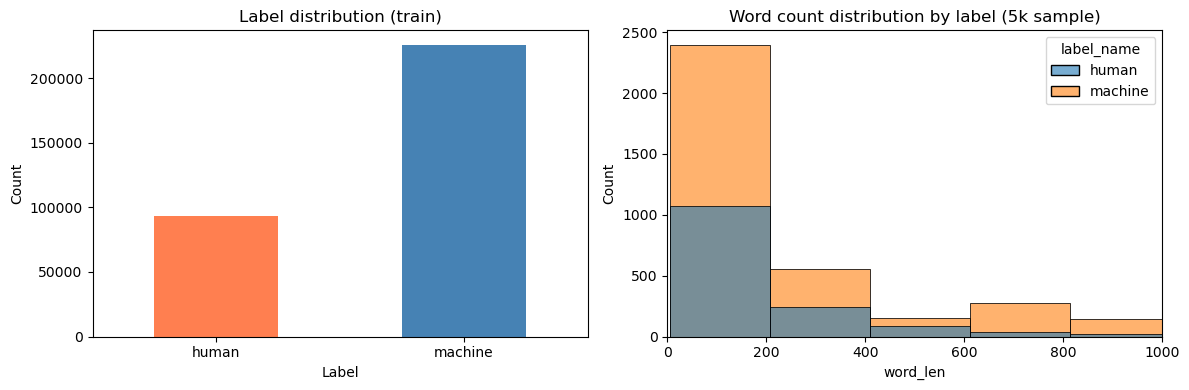

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label balance (train)
label_counts = df["label_name"].value_counts().sort_index()
label_counts.plot(kind="bar", ax=axes[0], color=["coral", "steelblue"])

axes[0].set_title("Label distribution (train)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Word length distribution by label (sample for speed)
sample = df.sample(min(5000, len(df)), random_state=42)

sns.histplot(
    data=sample,
    x="word_len",
    hue="label_name",
    bins=50,
    ax=axes[1],
    alpha=0.6
)

axes[1].set_title("Word count distribution by label (5k sample)")
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

## 7. Sample rows

In [11]:
train_df = dataset["train"].to_pandas()
train_df["label_name"] = train_df["label"].map({0: "machine", 1: "human"})

print("Sample machine-generated (label=0):")
sample_m = train_df[train_df["label"] == 0].sample(1).iloc[0]
print(f"  src: {sample_m['src']}")
print(f"  text (first 300 chars): {sample_m['text'][:300]}...")

print("\nSample human-written (label=1):")
sample_h = train_df[train_df["label"] == 1].sample(1).iloc[0]
print(f"  src: {sample_h['src']}")
print(f"  text (first 300 chars): {sample_h['text'][:300]}...")

Sample machine-generated (label=0):
  src: squad_machine_continuation_gpt_j
  text (first 300 chars): Oxygen is a chemical element with symbol O and atomic number 8. It is a member of the chalcogen group on the periodic table and is a highly reactive nonmetal that combines with most elements to form compounds, in particular oxides, hydroxides or peroxides. The oxygen atom has three valence electrons...

Sample human-written (label=1):
  src: wp_human
  text (first 300 chars): I looked up from the deep gash on my wrist, where blood should of been, there was simply a vary of wires and metal frame. "Okay, this is different..." I said glancing over to my girl freind. "Johnny, you're like Anakin Skywalker from that movie you love so much" she said, examining the wires. "I'm s...


## Summary

- Splits: train / validation / test with ~319k / ~57k / ~61k rows.
- Columns: `text`, `label` ( 0=machine, 1=human), `src` (domain/source).
- Domains: Many unique `src` values; useful for domain-specific analysis and OOD evaluation.
- Next steps: sentence embeddings (e.g. Sentence-BERT), then SVDD/HRN for unknown-aware detection.